# Binary Classification Baseline Modeling

In the previous notebooks, I explored the asthma drug efficacy dataset and prepared train-test datasets for machine learning.

The binary classification target is:

- `had_exacerbation = 0`: no exacerbation during the post-index year
- `had_exacerbation = 1`: at least one exacerbation during the post-index year

The goal of this notebook is to build baseline classification models to predict whether a patient will experience at least one exacerbation after treatment initiation.

Because the positive class is only about 11.5% of the dataset, this is an imbalanced classification problem. Therefore, I should not rely only on accuracy. I will compare models using several metrics, including recall, precision, F1-score, ROC-AUC, and PR-AUC.

## Modeling Plan

In this notebook, I will:

1. Load the processed train-test datasets.
2. Confirm the shape and class balance.
3. Build a simple dummy classifier as a baseline.
4. Build a logistic regression model.
5. Compare model performance using classification metrics.
6. Interpret why accuracy alone can be misleading in this dataset.

I will start with simple models first before moving to more complex models such as Random Forest or XGBoost.

In [1]:
# Libraries importing

import pandas as pd
import numpy as np

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report
)

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", "{:.4f}".format)

## Load Processed Train-Test Data

I will load the processed datasets saved from Notebook 02. These files already contain the selected log-charge feature set and the train-test split.

The feature matrices are:

- `X_train_log.csv`
- `X_test_log.csv`

The binary target files are:

- `y_binary_train.csv`
- `y_binary_test.csv`

In [2]:
# loading data

X_train = pd.read_csv("../data/processed/X_train_log.csv")
X_test = pd.read_csv("../data/processed/X_test_log.csv")

y_train = pd.read_csv("../data/processed/y_binary_train.csv").squeeze()
y_test = pd.read_csv("../data/processed/y_binary_test.csv").squeeze()

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (14572, 16)
X_test shape: (3643, 16)
y_train shape: (14572,)
y_test shape: (3643,)


In [3]:
# To check features

X_train.head()

,index_age,total_pre_index_cannisters_365,pneumonia,sinusitis,acute_bronchitis,acute_laryngitis,upper_respiratory_infection,gerd,rhinitis,adherence,pre_asthma_days,pre_asthma_pharma_charge,drug_s,female,log_charges,log_asthma_charge
0,38,0,1,0,0,0,0,0,0,0.0845,1,2.2800,0,0,7.3612,0.8242
1,30,0,0,1,0,0,1,1,0,0.1689,1,10.6500,0,1,7.4501,2.3656
2,27,0,0,0,0,0,0,0,1,0.5722,0,3.0900,0,0,6.2888,1.1282
3,55,0,0,1,1,0,1,0,1,0.5913,2,1.0000,0,1,10.3863,0.0000
4,35,1,1,0,0,0,0,0,0,0.4223,0,31.3900,0,1,7.3335,3.4465


In [4]:
# To check target balance

target_balance = pd.DataFrame({
    "train_count": y_train.value_counts().sort_index(),
    "train_percent": y_train.value_counts(normalize=True).sort_index() * 100,
    "test_count": y_test.value_counts().sort_index(),
    "test_percent": y_test.value_counts(normalize=True).sort_index() * 100
})

target_balance

,train_count,train_percent,test_count,test_percent
had_exacerbation,,,,
0,12899,88.5191,3225,88.5259
1,1673,11.4809,418,11.4741


## Target Balance Check

The processed training and test datasets loaded correctly.

The training set contains **14572 patients**, and the test set contains **3643 patients**. The feature matrix contains **16 predictors**.

The class distribution is very similar between the training and test sets. This confirms that the stratified train-test split from the preprocessing notebook worked correctly.

Because only about **11.4 %** of patients had at least one exacerbation, this remains an imbalanced classification problem. I will need to evaluate models using metrics beyond accuracy.

## Model Evaluation Function

To compare different classification models consistently, I will create a helper function that calculates several performance metrics.

For this imbalanced problem, the most important metrics include:

- **Accuracy:** overall proportion of correct predictions.
- **Precision:** among patients predicted to have exacerbation, how many actually had exacerbation.
- **Recall:** among patients who actually had exacerbation, how many were identified by the model.
- **F1-score:** balance between precision and recall.
- **ROC-AUC:** ranking ability across classification thresholds.
- **PR-AUC:** precision-recall performance, especially useful for imbalanced datasets.

The positive class is `1`, meaning the patient had at least one exacerbation.

In [6]:
# Evaluation function

def evaluate_classifier(model_name, y_true, y_pred, y_proba=None):
    """
    Evaluate a binary classification model and return key metrics.
    
    Parameters
    ----------
    model_name : str
        Name of the model.
    y_true : array-like
        True binary labels.
    y_pred : array-like
        Predicted binary labels.
    y_proba : array-like, optional
        Predicted probabilities for the positive class.
    
    Returns
    -------
    pd.DataFrame
        One-row dataframe with classification metrics.
    """
    
    results = {
        "model": model_name,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0)
    }
    
    if y_proba is not None:
        results["roc_auc"] = roc_auc_score(y_true, y_proba)
        results["pr_auc"] = average_precision_score(y_true, y_proba)
    else:
        results["roc_auc"] = np.nan
        results["pr_auc"] = np.nan
    
    return pd.DataFrame([results])
    

## Baseline Model: Dummy Classifier

Before building real machine learning models, I will create a dummy baseline model.

The dummy classifier does not learn meaningful relationships from the features. Instead, it uses a simple rule. Here, I will use the `most_frequent` strategy, which always predicts the majority class.

Since most patients did not have an exacerbation, this dummy model will likely predict every patient as `0`.

This baseline is important because any useful model should perform better than this simple majority-class rule.

In [7]:
# Training Dummy Classifier

dummy_clf = DummyClassifier(strategy="most_frequent")

dummy_clf.fit(X_train, y_train)

dummy_pred = dummy_clf.predict(X_test)
dummy_proba = dummy_clf.predict_proba(X_test)[:, 1]

In [8]:
# Evaluate Dummy Classifier

dummy_results = evaluate_classifier(
    model_name="Dummy Classifier",
    y_true=y_test,
    y_pred=dummy_pred,
    y_proba=dummy_proba
)

dummy_results

,model,accuracy,precision,recall,f1,roc_auc,pr_auc
0,Dummy Classifier,0.8853,0.0000,0.0000,0.0000,0.5000,0.1147


In [9]:
# Confusion matrix for that dummy classifier
confusion_matrix(y_test, dummy_pred)

array([[3225,    0],
       [ 418,    0]])

In [10]:
# Classification report

print(classification_report(y_test, dummy_pred, zero_division=0))


              precision    recall  f1-score   support

           0       0.89      1.00      0.94      3225
           1       0.00      0.00      0.00       418

    accuracy                           0.89      3643
   macro avg       0.44      0.50      0.47      3643
weighted avg       0.78      0.89      0.83      3643



## Observation: Dummy Classifier

The dummy classifier always predicts the majority class, which is `0` or no exacerbation.

The model achieved an accuracy of **88.53%**, which may look high at first. However, this is misleading because **88.53%** of the test patients already belong to the no-exacerbation class.

The confusion matrix shows:

| Actual / Predicted | Predicted 0 | Predicted 1 |
|---|---:|---:|
| Actual 0 | 3,225 | 0 |
| Actual 1 | 418 | 0 |

This means the dummy classifier correctly classified all patients without exacerbation, but it failed to identify every patient who actually had an exacerbation.

For the positive class:

- Precision = **0.00**
- Recall = **0.00**
- F1-score = **0.00**

This confirms that accuracy alone is not a useful metric for this imbalanced classification problem. A clinically useful model should identify at least some patients who are at risk of post-index exacerbation.

## Model 1: Logistic Regression

After the dummy baseline, I will build a logistic regression model.

Logistic regression is a good first real model because it is simple, interpretable, and commonly used for binary classification problems. It estimates the probability that a patient belongs to the positive class, which in this project means having at least one post-index exacerbation.

Because the dataset contains variables on different scales, I will use `StandardScaler` inside a pipeline before fitting logistic regression. Scaling is important for logistic regression because variables such as age, charges, and adherence have different numeric ranges.

I will first fit a standard logistic regression model without class weighting. Then I can compare it with a class-weighted version later.

In [11]:
# Train Logistic Regression

log_reg = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=1000, random_state=22))
    ]
)

log_reg.fit(X_train, y_train)

log_reg_pred = log_reg.predict(X_test)
log_reg_proba = log_reg.predict_proba(X_test)[:, 1]

In [12]:
# To Evaluate Logistic Regression

log_reg_results = evaluate_classifier(
    model_name="Logistic Regression",
    y_true=y_test,
    y_pred=log_reg_pred,
    y_proba=log_reg_proba
)

log_reg_results

,model,accuracy,precision,recall,f1,roc_auc,pr_auc
0,Logistic Regression,0.8853,0.0000,0.0000,0.0000,0.5631,0.1354


In [13]:
# Confusion matrix

confusion_matrix(y_test, log_reg_pred)

array([[3225,    0],
       [ 418,    0]])

In [14]:
# Classification report

print(classification_report(y_test, log_reg_pred, zero_division=0))

              precision    recall  f1-score   support

           0       0.89      1.00      0.94      3225
           1       0.00      0.00      0.00       418

    accuracy                           0.89      3643
   macro avg       0.44      0.50      0.47      3643
weighted avg       0.78      0.89      0.83      3643



In [15]:
# Compare Dummy vs Logistic Regression

baseline_results = pd.concat(
    [dummy_results, log_reg_results],
    ignore_index=True
)

baseline_results

,model,accuracy,precision,recall,f1,roc_auc,pr_auc
0,Dummy Classifier,0.8853,0.0000,0.0000,0.0000,0.5000,0.1147
1,Logistic Regression,0.8853,0.0000,0.0000,0.0000,0.5631,0.1354


## Observation: Standard Logistic Regression

The standard logistic regression model achieved an accuracy of **88.53%**, which is identical to the dummy classifier.

However, the confusion matrix shows that logistic regression predicted every test patient as `0`, meaning no exacerbation. Therefore, the model failed to identify any patients who actually had at least one exacerbation.

For the positive class:

- Precision = **0.00**
- Recall = **0.00**
- F1-score = **0.00**

This result shows that the default classification threshold of **0.50** is not useful for this imbalanced dataset. Since only about **11.47%** of test patients had an exacerbation, predicted probabilities may rarely exceed 0.50.

However, logistic regression still performed slightly better than the dummy classifier in terms of ranking metrics:

- ROC-AUC improved from **0.5000** to **0.5631**
- PR-AUC improved from **0.1147** to **0.1354**

This suggests that the model learned some weak signal from the predictors, even though the default threshold did not produce any positive predictions. The next step is to try class weighting and threshold adjustment.

## Model 2: Logistic Regression with Class Weighting

The standard logistic regression model predicted all patients as the majority class. This happened because the dataset is imbalanced and the default threshold of 0.50 may be too conservative for the positive class.

To address this, I will try logistic regression with `class_weight="balanced"`.

This tells the model to give more importance to the minority class during training. In this dataset, the minority class is patients who had at least one exacerbation.

The goal is not necessarily to maximize accuracy, but to improve the model's ability to detect patients at risk of exacerbation.

In [ ]:
# Lets Train Class-Weighted Logistic Regression

log_reg_balanced = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            max_iter=1000,
            random_state=22,
            class_weight="balanced"
        ))
    ]
)

log_reg_balanced.fit(X_train, y_train)

log_reg_balanced_pred = log_reg_balanced.predict(X_test)
log_reg_balanced_proba = log_reg_balanced.predict_proba(X_test)[:, 1]

In [17]:
# Evaluate Class-Weighted Logistic Regression

log_reg_balanced_results = evaluate_classifier(
    model_name="Logistic Regression Balanced",
    y_true=y_test,
    y_pred=log_reg_balanced_pred,
    y_proba=log_reg_balanced_proba
)

log_reg_balanced_results

,model,accuracy,precision,recall,f1,roc_auc,pr_auc
0,Logistic Regression Balanced,0.5561,0.1373,0.5431,0.2192,0.5621,0.1349


In [18]:
# Confusion Matrix

confusion_matrix(y_test, log_reg_balanced_pred)

array([[1799, 1426],
       [ 191,  227]])

In [19]:
# Classification report

print(classification_report(y_test, log_reg_balanced_pred, zero_division=0))


              precision    recall  f1-score   support

           0       0.90      0.56      0.69      3225
           1       0.14      0.54      0.22       418

    accuracy                           0.56      3643
   macro avg       0.52      0.55      0.45      3643
weighted avg       0.82      0.56      0.64      3643



In [20]:
# Comparing models so far

baseline_results = pd.concat(
    [dummy_results, log_reg_results, log_reg_balanced_results],
    ignore_index=True
)

baseline_results

,model,accuracy,precision,recall,f1,roc_auc,pr_auc
0,Dummy Classifier,0.8853,0.0000,0.0000,0.0000,0.5000,0.1147
1,Logistic Regression,0.8853,0.0000,0.0000,0.0000,0.5631,0.1354
2,Logistic Regression Balanced,0.5561,0.1373,0.5431,0.2192,0.5621,0.1349


## Observation: Class-Weighted Logistic Regression

Class weighting changed the behavior of logistic regression substantially.

The standard logistic regression model predicted no positive cases, but the class-weighted logistic regression model identified **227 out of 418** patients who actually had at least one exacerbation.

The positive-class recall improved from **0.00** to **0.5431**, meaning the model detected about **54.31%** of patients with post-index exacerbations.

However, this improvement came with a major trade-off. The model also produced **1,426 false positives**, meaning many patients were predicted to have an exacerbation even though they did not.

The precision was only **0.1373**, which means that among patients predicted as high risk, only about **13.73%** actually had an exacerbation.

The overall accuracy dropped from **88.53%** to **55.61%** because the model no longer simply predicts the majority class.

This result shows an important trade-off in imbalanced healthcare classification:

- Standard logistic regression gives high accuracy but misses all positive cases.
- Class-weighted logistic regression detects more positive cases but creates many false positives.

For a clinical risk-screening problem, higher recall may be useful if the goal is to identify patients who may need closer monitoring. However, the low precision means the model is not yet very specific or reliable for decision-making.

## Threshold Adjustment for Logistic Regression

By default, logistic regression classifies a patient as positive only when the predicted probability is at least 0.50.

In this dataset, the positive class is rare, so many predicted probabilities may be below 0.50. This explains why the standard logistic regression model predicted all patients as negative.

To better understand the model behavior, I will evaluate different probability thresholds. Lowering the threshold may increase recall, but it will usually decrease precision.

In [21]:
# Check Predicted Probability Distribution

pd.Series(log_reg_proba).describe()

count   3643.0000
mean       0.1145
std        0.0270
min        0.0260
25%        0.0959
50%        0.1119
75%        0.1295
max        0.3161
dtype: float64

In [23]:
# Plotting libraries 

import matplotlib.pyplot as plt

import seaborn as sns



sns.set_theme(style="whitegrid")

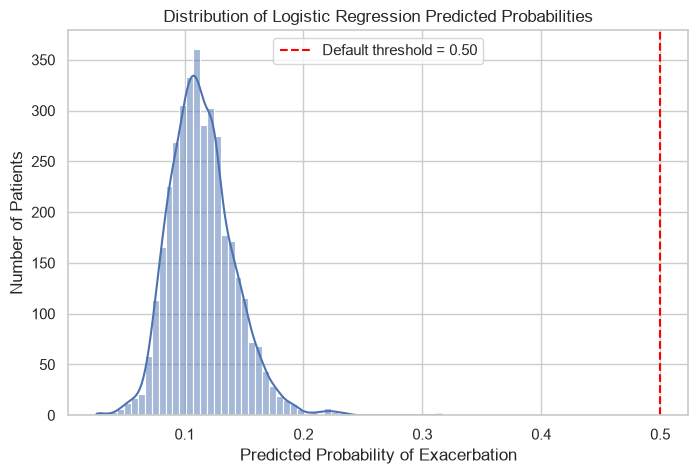

In [ ]:
# Plotting Predicted Probabilities

plt.figure(figsize=(8, 5))

sns.histplot(log_reg_proba, bins=50, kde=True)

plt.axvline(0.50, color="red", linestyle="--", label="Default threshold = 0.50")

plt.title("Distribution of Logistic Regression Predicted Probabilities")
plt.xlabel("Predicted Probability of Exacerbation")
plt.ylabel("Number of Patients")
plt.legend()
plt.show()

In [30]:
# Evaluating Several Thresholds

thresholds = [0.05, 0.10, 0.12, 0.15, 0.20, 0.25, 0.30, 0.40, 0.50]

threshold_results = []

for threshold in thresholds:
    y_pred_threshold = (log_reg_proba >= threshold).astype(int)
    
    threshold_results.append({
        "threshold": threshold,
        "accuracy": accuracy_score(y_test, y_pred_threshold),
        "precision": precision_score(y_test, y_pred_threshold, zero_division=0),
        "recall": recall_score(y_test, y_pred_threshold, zero_division=0),
        "f1": f1_score(y_test, y_pred_threshold, zero_division=0)
    })

threshold_results = pd.DataFrame(threshold_results)

threshold_results


,threshold,accuracy,precision,recall,f1
0,0.0500,0.1183,0.1149,0.9976,0.2061
1,0.1000,0.3678,0.1294,0.7871,0.2222
2,0.1200,0.6058,0.1390,0.4689,0.2144
3,0.1500,0.8147,0.1380,0.1172,0.1268
4,0.2000,0.8800,0.0476,0.0024,0.0046
5,0.2500,0.8850,0.0000,0.0000,0.0000
6,0.3000,0.8850,0.0000,0.0000,0.0000
7,0.4000,0.8853,0.0000,0.0000,0.0000
8,0.5000,0.8853,0.0000,0.0000,0.0000


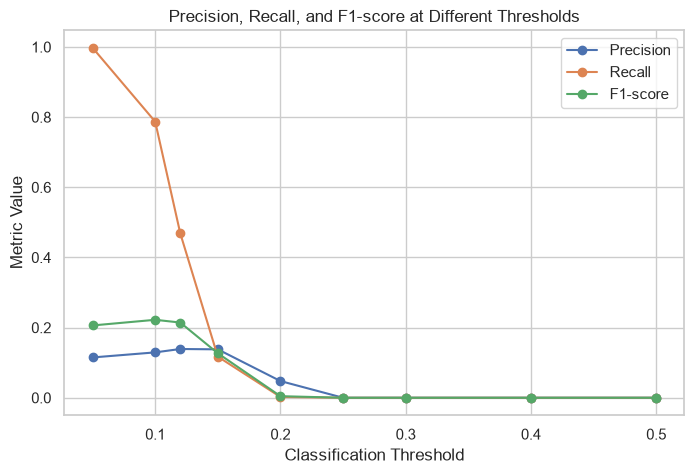

In [31]:
# Plotting Precision-Recall Trade-Off by Threshold

plt.figure(figsize=(8, 5))

plt.plot(threshold_results["threshold"], threshold_results["precision"], marker="o", label="Precision")
plt.plot(threshold_results["threshold"], threshold_results["recall"], marker="o", label="Recall")
plt.plot(threshold_results["threshold"], threshold_results["f1"], marker="o", label="F1-score")

plt.title("Precision, Recall, and F1-score at Different Thresholds")
plt.xlabel("Classification Threshold")
plt.ylabel("Metric Value")
plt.legend()
plt.show()

## Observation: Threshold Adjustment

The predicted probabilities from the standard logistic regression model were mostly low. The mean predicted probability was about **0.1145**, the median was about **0.1119**, and the maximum predicted probability was only **0.3161**. This explains why the default threshold of **0.50** predicted all patients as negative.

I included **0.12** as an exploratory threshold because it is close to the center of the predicted probability distribution. This was not chosen as a final threshold, but it helps show how the model behaves near the typical predicted risk level.

The threshold results show a clear trade-off:

- At a very low threshold such as **0.05**, recall was very high (**0.9976**), but accuracy was very low because almost everyone was predicted as positive.
- At **0.10**, recall was still high (**0.7871**) and F1-score was the highest among the tested thresholds (**0.2222**).
- At **0.12**, recall decreased to **0.4689**, but accuracy improved to **0.6058**.
- At thresholds of **0.25 or higher**, the model predicted almost no positive cases.

This shows that the classification threshold has a major effect on model behavior. For a clinical screening problem, a lower threshold may be useful if the goal is to identify more patients at risk. However, lower thresholds also create many false positives.

At this stage, I will not choose a final threshold based only on the test set. In a more complete workflow, threshold selection should be done using training data, cross-validation, or a separate validation set. Here, the threshold analysis is mainly used to understand model behavior.


In [32]:
# To identify the best threshold by F1 from our tested list

best_threshold_row = threshold_results.loc[threshold_results["f1"].idxmax()]

best_threshold_row

threshold   0.1000
accuracy    0.3678
precision   0.1294
recall      0.7871
f1          0.2222
Name: 1, dtype: float64

## Best Threshold Among Tested Values

Among the tested thresholds, the best F1-score was observed at threshold **0.10**.

This does not mean that 0.10 is the final best threshold for deployment. It only means that among the small set of thresholds tested here, 0.10 gave the best balance between precision and recall on the test set.

For a more rigorous workflow, I should tune the threshold using cross-validation or a validation set instead of selecting it directly from the test set.

## Model 3: Random Forest Classifier

After logistic regression, I will try a Random Forest classifier.

Random Forest is a tree-based ensemble model. Unlike logistic regression, it can capture non-linear relationships and interactions between variables. It also does not require feature scaling.

Because this dataset is imbalanced, I will first try a Random Forest model with `class_weight="balanced"` so that the minority class receives more importance during training.

The goal is to check whether a more flexible model can improve detection of patients who had at least one post-index exacerbation.

In [33]:
# importing RF

from sklearn.ensemble import RandomForestClassifier

In [ ]:
# Training Random Forest

rf_clf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    class_weight="balanced",
    random_state=22,
    n_jobs=-1
)

rf_clf.fit(X_train, y_train)

rf_pred = rf_clf.predict(X_test)
rf_proba = rf_clf.predict_proba(X_test)[:, 1]


In [35]:
# Evaluate Random Forest

rf_results = evaluate_classifier(
    model_name="Random Forest Balanced",
    y_true=y_test,
    y_pred=rf_pred,
    y_proba=rf_proba
)

rf_results



,model,accuracy,precision,recall,f1,roc_auc,pr_auc
0,Random Forest Balanced,0.8729,0.1186,0.0167,0.0294,0.5170,0.1235


In [36]:
# Confusion matrix

confusion_matrix(y_test, rf_pred)


array([[3173,   52],
       [ 411,    7]])

In [37]:
# Classification report

print(classification_report(y_test, rf_pred, zero_division=0))


              precision    recall  f1-score   support

           0       0.89      0.98      0.93      3225
           1       0.12      0.02      0.03       418

    accuracy                           0.87      3643
   macro avg       0.50      0.50      0.48      3643
weighted avg       0.80      0.87      0.83      3643



In [38]:
# Lets compare All Baseline Models

all_baseline_results = pd.concat(
    [
        dummy_results,
        log_reg_results,
        log_reg_balanced_results,
        rf_results
    ],
    ignore_index=True
)

all_baseline_results


,model,accuracy,precision,recall,f1,roc_auc,pr_auc
0,Dummy Classifier,0.8853,0.0000,0.0000,0.0000,0.5000,0.1147
1,Logistic Regression,0.8853,0.0000,0.0000,0.0000,0.5631,0.1354
2,Logistic Regression Balanced,0.5561,0.1373,0.5431,0.2192,0.5621,0.1349
3,Random Forest Balanced,0.8729,0.1186,0.0167,0.0294,0.5170,0.1235


## Observation: Random Forest Baseline

The Random Forest model had an accuracy of **87.29%**, which appears high, but this is again influenced by the class imbalance.

The confusion matrix shows that the model identified only **7 out of 418** patients who actually had at least one exacerbation. This resulted in a very low positive-class recall of **0.0167**.

The model predicted only a small number of patients as positive:

- True positives: **7**
- False positives: **52**

This means the model was conservative in assigning patients to the positive class. Although the number of false positives was low, the model missed most patients who actually had an exacerbation.

Compared with class-weighted logistic regression, Random Forest had much higher accuracy but much lower recall. For this clinical screening-style problem, this is not ideal because identifying at-risk patients is an important goal.

The ROC-AUC was **0.5170**, and the PR-AUC was **0.1235**, only slightly above the dummy baseline. This suggests that the Random Forest baseline did not rank patients by exacerbation risk very well in its current form.

Overall, the Random Forest baseline did not improve minority-class detection. More tuning or alternative models may be needed.


## Random Forest Feature Importance

Random Forest provides feature importance scores that estimate how much each predictor contributed to the model's decisions.

These importance scores should be interpreted carefully. They do not prove causality, but they can help identify which variables are useful for prediction.

In [39]:
rf_feature_importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": rf_clf.feature_importances_
}).sort_values("importance", ascending=False)

rf_feature_importance

,feature,importance
14,log_charges,0.2062
0,index_age,0.1615
15,log_asthma_charge,0.1448
11,pre_asthma_pharma_charge,0.1448
9,adherence,0.1044
10,pre_asthma_days,0.0531
1,total_pre_index_cannisters_365,0.0330
8,rhinitis,0.0228
3,sinusitis,0.0225
6,upper_respiratory_infection,0.0223


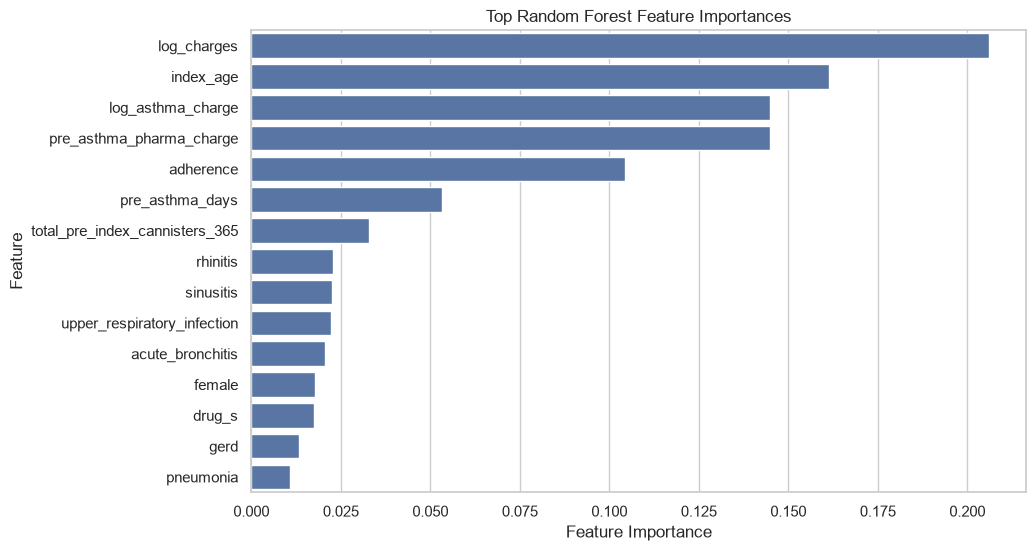

In [40]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=rf_feature_importance.head(15),
    x="importance",
    y="feature"
)

plt.title("Top Random Forest Feature Importances")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.show()

## Observation: Random Forest Feature Importance

The Random Forest feature importance results suggest that the most influential predictors were:

1. **log_charges**
2. **index_age**
3. **log_asthma_charge**
4. **pre_asthma_pharma_charge**
5. **adherence**

These variables are mostly related to baseline healthcare utilization, age, asthma-related charges, medication cost, and treatment adherence.

This pattern is reasonable because patients with different baseline healthcare charges or medication-use patterns may have different asthma severity or healthcare engagement before treatment. However, these feature importance values do not prove causality. They only show which variables the Random Forest used most often for prediction.

Interestingly, diagnosis variables such as `acute_bronchitis`, `gerd`, and `pneumonia` had lower feature importance than the continuous charge and adherence variables. This may suggest that healthcare utilization and cost-related features capture broader information about patient severity than individual diagnosis indicators.

In [41]:
# Sorting models by PR-AUC and F1

all_baseline_results.sort_values(
    by=["f1", "pr_auc"],
    ascending=False
)

,model,accuracy,precision,recall,f1,roc_auc,pr_auc
2,Logistic Regression Balanced,0.5561,0.1373,0.5431,0.2192,0.5621,0.1349
3,Random Forest Balanced,0.8729,0.1186,0.0167,0.0294,0.5170,0.1235
1,Logistic Regression,0.8853,0.0000,0.0000,0.0000,0.5631,0.1354
0,Dummy Classifier,0.8853,0.0000,0.0000,0.0000,0.5000,0.1147


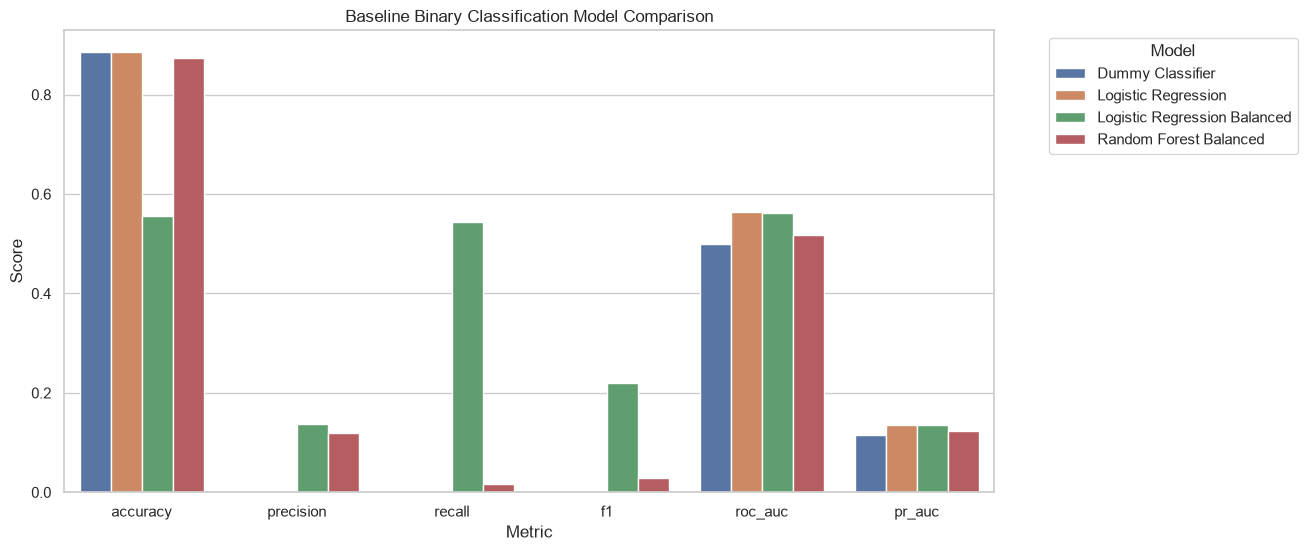

In [42]:
# Ploting model comparison

metrics_to_plot = ["accuracy", "precision", "recall", "f1", "roc_auc", "pr_auc"]

model_results_long = all_baseline_results.melt(
    id_vars="model",
    value_vars=metrics_to_plot,
    var_name="metric",
    value_name="score"
)

plt.figure(figsize=(12, 6))

sns.barplot(
    data=model_results_long,
    x="metric",
    y="score",
    hue="model"
)

plt.title("Baseline Binary Classification Model Comparison")
plt.xlabel("Metric")
plt.ylabel("Score")
plt.legend(title="Model", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()


# Summary of Baseline Binary Classification Modeling

In this notebook, I built several baseline models for predicting whether a patient had at least one asthma exacerbation during the post-index year.

The models compared were:

1. Dummy classifier
2. Standard logistic regression
3. Class-weighted logistic regression
4. Class-weighted Random Forest

The dummy classifier achieved high accuracy by predicting all patients as the majority class, but it completely failed to identify positive cases.

Standard logistic regression behaved similarly at the default threshold of 0.50. It predicted all test patients as negative, resulting in zero recall for the positive class. However, its ROC-AUC and PR-AUC were slightly better than the dummy classifier, suggesting that it learned some weak ranking signal.

Class-weighted logistic regression performed the best among these baseline models for detecting positive cases. It achieved a recall of **0.5431**, identifying **227 out of 418** patients who actually had at least one exacerbation. However, this came with many false positives and low precision.

The Random Forest baseline did not perform well for the minority class. It had high accuracy but very low recall, identifying only **7 out of 418** positive cases.

Overall, the most useful baseline model for minority-class detection was **class-weighted logistic regression**. However, the low precision and modest PR-AUC show that the problem remains difficult.

The next modeling step should focus on improving minority-class prediction using better model tuning, threshold selection, cross-validation, and possibly additional models such as Gradient Boosting or XGBoost.